<a href="https://colab.research.google.com/github/elessardari/IDC-MaIE_2026A/blob/main/icd_taller3_va_continuas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **¡¡ ANTES DE EMPEZAR !!**

Deshabilita autocompletar con IA. Esta acción te ayudará a aprender de verdad. Si estás en Colab sigue estos pasos:



1.   Ir a Herramientas \ Configuración \ Asistencia de IA
2.   Desactivar la casilla **"Mostrar autocompletado impulsado por IA"**
3.   Activar la casilla **"Ocultar funciones de IA generativa"**


# **SIMULACIÓN DE VARIABLES ALEATORIAS A PARTIR DE DISTRIBUCIONES**

Antes de trabajar con variables aleatorias continuas, apliquemos el método de la inversa de la CDF para generar variables aleatorias con cierta distribución.

# Reto 0: La Cafetería:

Usted está asesorando a una cafetería local para estimar sus ganancias diarias. Sabe que reciben **150 clientes al día** entre las 8:00 a.m. y las 8:00 p.m. (20:00).

A través de la observación, ha determinado dos comportamientos clave:

**1. La Hora de Llegada:**
Los clientes no llegan de manera uniforme. Hay un pico de oficinistas a las 10:00 a.m. y un pico de estudiantes a las 3:00 p.m. (15:00). La probabilidad de que un cliente llegue en una hora específica está dada por la siguiente Función de Masa:
* `Horas: 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20`
* `Probabilidades: 2%, 8%, 20%, 10%, 5%, 5%, 10%, 20%, 10%, 5%, 3%, 1%, 1%`

**2. El Tipo de Consumo:**
* **El Turno Mañana (Antes de las 12:00 m):** La gente tiene prisa. Tienen un **80%** de probabilidad de pedir el *Café Estándar* (\$1 USD) y un 20% de pedir el *Café de Especialidad* (\$2 USD).
* **El Turno Tarde (12:00 m en adelante):** La gente va a relajarse o estudiar. Tienen un **70%** de probabilidad de pedir el *Café de Especialidad* y un 30% de pedir el *Estándar*.

**Entregable:**
Simular 1,000 días completos de operación para encontrar la distribución de las ganancias diarias. ¿Cuál es la probabilidad de que las ganancias estén por debajo de \$ 250 USD?

**Nota:** La función `np.random.rand()` disponible en la librería `numpy` genera un número aleatorio entre 0 y 1 con distribución uniforme.

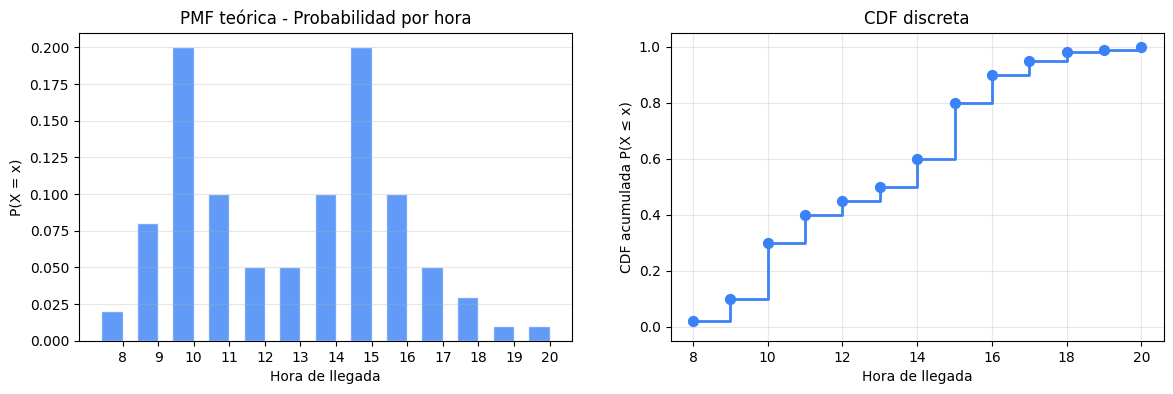

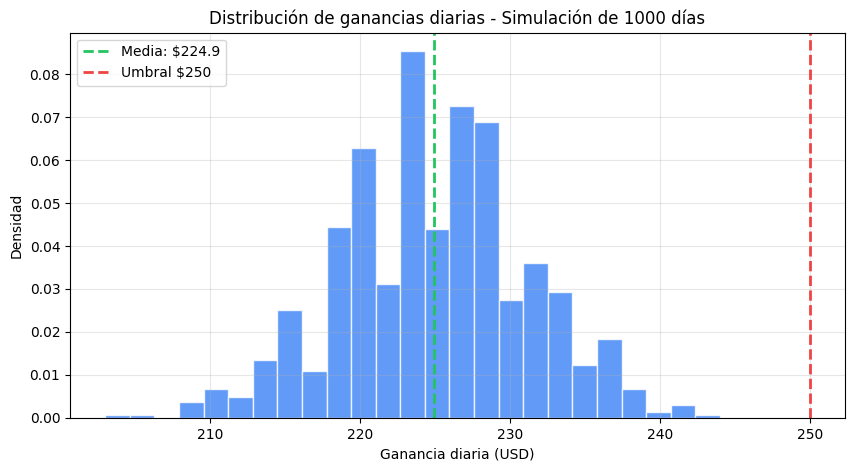

Distribución de ganancias diarias (simulación de 1000 días)
Media: $224.94 USD
Desviación estándar: $6.20 USD
Mínimo: $203 USD | Máximo: $244 USD

► Probabilidad de que las ganancias estén por debajo de $250 USD: 100.00%


In [1]:
# --- CÓDIGO PROBLEMA CAFETERÍA ---
# Método de la inversa de la CDF para simular variables aleatorias

import numpy as np
import matplotlib.pyplot as plt

# Parámetros
N_DIAS = 1000
N_CLIENTES = 150
HORAS = np.array([8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20])
PROB_HORAS = np.array([0.02, 0.08, 0.20, 0.10, 0.05, 0.05, 0.10, 0.20, 0.10, 0.05, 0.03, 0.01, 0.01])

# CDF acumulada para las horas
CDF_HORAS = np.cumsum(PROB_HORAS)

def simular_hora_llegada():
    """Usa np.random.rand() y la inversa de la CDF para muestrear la hora de llegada."""
    u = np.random.rand()
    # Buscar el primer índice donde CDF >= u
    idx = np.searchsorted(CDF_HORAS, u)
    return HORAS[np.minimum(idx, len(HORAS) - 1)]

# --- GRÁFICAS PARA SUSTENTAR EL MÉTODO DE LA INVERSA DE LA CDF ---

# 1. PMF (Función de Masa de Probabilidad) - La distribución teórica discreta
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# PMF teórica: barras para cada hora
axes[0].bar(HORAS - 0.3, PROB_HORAS, width=0.6, color='#3b82f6', edgecolor='white', alpha=0.8)
axes[0].set_xlabel('Hora de llegada')
axes[0].set_ylabel('P(X = x)')
axes[0].set_title('PMF teórica - Probabilidad por hora')
axes[0].set_xticks(HORAS)
axes[0].grid(True, alpha=0.3, axis='y')

# 2. CDF discreta (función escalonada)
axes[1].step(HORAS, CDF_HORAS, where='post', color='#3b82f6', linewidth=2)
axes[1].scatter(HORAS, CDF_HORAS, color='#3b82f6', s=50, zorder=5)
axes[1].set_xlabel('Hora de llegada')
axes[1].set_ylabel('CDF acumulada P(X ≤ x)')
axes[1].set_title('CDF discreta')
axes[1].set_ylim(-0.05, 1.05)
axes[1].grid(True, alpha=0.3)

def simular_consumo(hora):
    """Simula tipo de café según turno. Mañana (<12): 80% estándar, 20% especialidad. Tarde (>=12): 70% especialidad, 30% estándar."""
    u = np.random.rand()
    if hora < 12:  # Turno mañana
        return 1 if u < 0.80 else 2  # $1 estándar, $2 especialidad
    else:  # Turno tarde
        return 2 if u < 0.70 else 1

def simular_un_dia():
    """Simula un día completo: 150 clientes, cada uno con hora y consumo."""
    ganancia_dia = 0
    for _ in range(N_CLIENTES):
        hora = simular_hora_llegada()
        precio = simular_consumo(hora)
        ganancia_dia += precio
    return ganancia_dia

# Simulamos 1000 días
np.random.seed(95)
ganancias_diarias = np.array([simular_un_dia() for _ in range(N_DIAS)])

# Gráfica de ganancias diarias
plt.figure(figsize=(10, 5))
plt.hist(ganancias_diarias, bins=25, color='#3b82f6', edgecolor='white', alpha=0.8, density=True)
plt.axvline(ganancias_diarias.mean(), color='#22c55e', linestyle='--', linewidth=2, label=f'Media: ${ganancias_diarias.mean():.1f}')
plt.axvline(250, color='#ef4444', linestyle='--', linewidth=2, label='Umbral $250')
plt.xlabel('Ganancia diaria (USD)')
plt.ylabel('Densidad')
plt.title(f'Distribución de ganancias diarias - Simulación de {N_DIAS} días')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Entregable: Probabilidad de ganancias por debajo de $250
prob_bajo_250 = np.mean(ganancias_diarias < 250)
print(f"Distribución de ganancias diarias (simulación de {N_DIAS} días)")
print(f"Media: ${ganancias_diarias.mean():.2f} USD")
print(f"Desviación estándar: ${ganancias_diarias.std():.2f} USD")
print(f"Mínimo: ${ganancias_diarias.min():.0f} USD | Máximo: ${ganancias_diarias.max():.0f} USD")
print(f"\n► Probabilidad de que las ganancias estén por debajo de $250 USD: {prob_bajo_250:.2%}")


# **VARIABLES ALEATORIAS CONTINUAS**

Vamos a analizar el **S&P 500**, un índice que agrupa el valor de las acciones de las 500 empresas más grandes de Estados Unidos (Apple, Microsoft, Amazon, etc.). Este índice no solo es el termómetro más preciso de la economía global, sino que es el estándar contra el cual los inversores comparan el rendimiento de sus carteras en bolsa, e incluso de otras alternativas de inversión como los CDTs o el sector inmobiliario

En finanzas, rara vez analizamos el precio bruto de una acción. Lo que realmente nos importa es el **Retorno Diario**, es decir, qué porcentaje subió o bajó el precio respecto al día anterior. El retorno diario es un buen ejemplo de una **Variable Aleatoria Continua**:

**Haremos lo siguiente:**
1. Descargar los datos históricos del S&P 500 de los últimos 5 años.
2. Calcular los retornos diarios porcentuales.
3. Graficar un histograma para descubrir la "forma" de esta variable aleatoria.

In [2]:
# ==========================================
# 0. PREPARACIÓN E INSTALACIÓN DE LIBRERÍAS
# ==========================================

# Instalamos la librería yfinance (Yahoo Finance)
!pip install yfinance -q

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Configuramos un estilo limpio para las gráficas
plt.style.use('seaborn-v0_8-whitegrid')



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# ==========================================
# 1. DESCARGA DE DATOS
# ==========================================

print("Descargando datos del S&P 500...")
sp500 = yf.download('^GSPC', period='5y')

# Seleccionamos el cierre. Usamos doble corchete [['Close']] para asegurar
# que siga siendo un DataFrame (y no una Serie) y hacemos una copia limpia
sp500 = sp500[['Close']].copy()

# Veamos cómo son los datos que acabamos de descargar:
display(sp500.head())

# 1. Renombramos el título del índice (que originalmente es 'Date')
sp500 = sp500.rename_axis('fecha')

# 2. Renombramos la única columna de datos que tenemos
sp500.columns = ['precio']

print("\nPrimeros registros del precio:")
display(sp500.head())


Descargando datos del S&P 500...


[*********************100%***********************]  1 of 1 completed


Price,Close
Ticker,^GSPC
Date,
2021-03-08,3821.350098
2021-03-09,3875.439941
2021-03-10,3898.810059
2021-03-11,3939.340088
2021-03-12,3943.340088



Primeros registros del precio:


,precio
fecha,
2021-03-08,3821.350098
2021-03-09,3875.439941
2021-03-10,3898.810059
2021-03-11,3939.340088
2021-03-12,3943.340088


Para analizar una serie de tiempo financiera, el precio diario importa menos que los retornos porcentuales.
$$
  \text{retorno_diario}=\frac{\text{precio_actual}-\text{precio_ayer}}\dot{\text{precio_ayer}}
$$

Vamos a calcular estos retornos en nuestros datos

In [4]:
# ==========================================
# 2. PRE-PROCESAMIENTO
# ==========================================

# Usando.shift(1) movemos los datos una posición hacia abajo (el precio de ayer).

sp500['precio_ayer'] = sp500['precio'].shift(1)

# Calculamos el retorno porcentual de forma manual (para entender la matemática)
sp500['retorno_diario'] = (sp500['precio'] - sp500['precio_ayer']) / sp500['precio_ayer']

# Forma optimizada de Pandas (hace lo mismo que arriba)
# sp500['retorno_diario'] = sp500['precio'].pct_change() # Descomenta esta línea para usar la versión optimizada

# Limpiamos los datos nulos generados por el shift (la primera fila no tiene "ayer")
sp500.dropna(inplace=True)

display(sp500.head())


,precio,precio_ayer,retorno_diario
fecha,,,
2021-03-09,3875.439941,3821.350098,0.014155
2021-03-10,3898.810059,3875.439941,0.006030
2021-03-11,3939.340088,3898.810059,0.010395
2021-03-12,3943.340088,3939.340088,0.001015
2021-03-15,3968.939941,3943.340088,0.006492


## 1. Modelo de la Incertidumbre Financiera

Ahora que tenemos nuestra variable aleatoria continua (`retorno_diario`), vamos a graficar su histograma.

**Pregunta para analizar al ver la gráfica:** ¿Te recuerda a alguna de las distribuciones teóricas que vimos en las diapositivas de clase?

**Respuesta:** Sí. La forma del histograma recuerda a la **Distribución Normal**. Es una curva en forma de campana, simétrica alrededor de un valor central (cercano a 0%), con la mayoría de los datos concentrados en el centro y colas que decaen hacia los extremos. Según el material de clase, la normal es una de las distribuciones teóricas para variables aleatorias continuas; la PDF de la normal tiene precisamente esa forma. Los retornos diarios del S&P 500 tienden a comportarse así: días “normales” agrupados cerca del retorno medio, y eventos extremos (buenos o malos) en las colas.

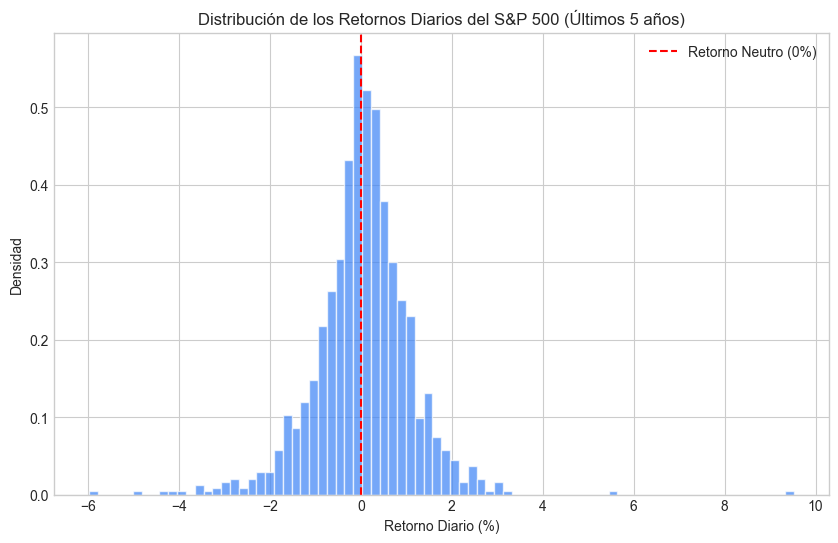

Retorno diario promedio: 0.0508%
Retorno anual promedio (aproximado): 12.81%

¿Es rentable invertir en la bolsa? Históricamente sí: el S&P 500 ha tenido un rendimiento anual positivo en promedio.


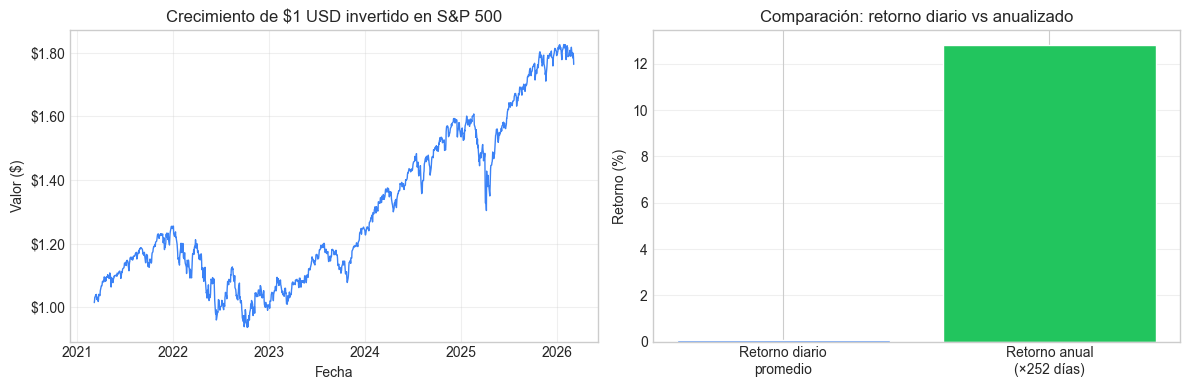

In [5]:
# ==========================================
# 3. HISTOGRAMA
# ==========================================

retornos = sp500['retorno_diario']*100 # Multiplicamos por 100 para verlo en porcentaje

plt.figure(figsize=(10, 6))
# Usamos density=True para que el área del histograma sume 1 (como una Función de Densidad PDF)
# Si density=False, en el eje vertical se mostrará el conteo de los datos que caen en cada bin
plt.hist(retornos, bins=80, color='#3b82f6', edgecolor='white', density=True, alpha=0.7)

plt.axvline(0, color='red', linestyle='dashed', linewidth=1.5, label='Retorno Neutro (0%)')

plt.title('Distribución de los Retornos Diarios del S&P 500 (Últimos 5 años)')
plt.xlabel('Retorno Diario (%)')
plt.ylabel('Densidad')
plt.legend()
plt.show()

# CALCULE EL RETORNO ANUAL PROMEDIO. ¿ES RENTABLE INVERTIR EN LA BOLSA?
# Retorno diario promedio (en decimal) * ~252 días hábiles = retorno anual aproximado
retorno_diario_promedio = sp500['retorno_diario'].mean()
retorno_anual_promedio = retorno_diario_promedio * 252  # 252 días de trading por año
print(f"Retorno diario promedio: {retorno_diario_promedio*100:.4f}%")
print(f"Retorno anual promedio (aproximado): {retorno_anual_promedio*100:.2f}%")
print(f"\n¿Es rentable invertir en la bolsa? Históricamente sí: el S&P 500 ha tenido un rendimiento anual positivo en promedio.")

# Sustento visual: retorno acumulado y comparación diario vs anual
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# Retorno acumulado (crecimiento de $1 invertido)
retorno_acum = (1 + sp500['retorno_diario']).cumprod()
axes[0].plot(retorno_acum.index, retorno_acum.values, color='#3b82f6', linewidth=1)
axes[0].set_title('Crecimiento de $1 USD invertido en S&P 500')
axes[0].set_ylabel('Valor ($)')
axes[0].set_xlabel('Fecha')
axes[0].grid(True, alpha=0.3)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:.2f}'))
# Comparación retorno diario vs anual
axes[1].bar(['Retorno diario\npromedio', 'Retorno anual\n(×252 días)'], 
            [retorno_diario_promedio*100, retorno_anual_promedio*100], 
            color=['#3b82f6', '#22c55e'], edgecolor='white')
axes[1].axhline(0, color='gray', linestyle='-', linewidth=0.5)
axes[1].set_ylabel('Retorno (%)')
axes[1].set_title('Comparación: retorno diario vs anualizado')
axes[1].grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


**¿Es rentable invertir en la bolsa?**  
Sí, históricamente el S&P 500 ha tenido un **retorno anual promedio positivo**. El valor exacto se obtiene multiplicando el retorno diario promedio por aproximadamente 252 días hábiles al año. Aunque hay volatilidad y periodos de caída (como se ve en los percentiles y los “cisnes negros”), a largo plazo el índice ha tendido a crecer. La decisión depende del horizonte de inversión y la tolerancia al riesgo.

## 2. Cuartiles y Percentiles

Hasta ahora hemos visto el histograma, que nos muestra dónde se agrupan los datos. Pero, ¿cómo podemos *ranquear* esos datos? Para eso usamos los **Percentiles**.

Imaginemos que tomamos los 1,250 días de retornos del S&P 500 y los formamos en una fila:
* A la extrema izquierda ponemos el peor día de todos (la mayor caída).
* A la extrema derecha ponemos el mejor día (la mayor ganancia).
* En el medio quedan los días "normales".

Si empezamos a caminar desde la izquierda (los peores días) hacia la derecha, y nos detenemos cuando hemos pasado exactamente al **10%** de los datos de la fila, el valor del retorno en ese punto exacto es el **Percentil 10**. Significa que el 10% de los días fueron peores que ese valor, y el 90% fueron mejores.

Matemáticamente, el **Percentil $p$** es el valor $x$ donde la probabilidad acumulada es exactamente $p\%$.
* En fórmula, es el valor de $x$ para el que $F_X(x) = p/100$

Por su parte, los **Cuartiles** son simplemente percentiles con nombres especiales que cortan nuestra fila de datos en cuatro pedazos iguales (de 25% en 25%):
* **Q1 (Primer Cuartil o Percentil 25):** Sólo el 25% de los datos es menor a este valor.
* **Q2 (Mediana o Percentil 50):** Corta la fila exactamente por la mitad.
* **Q3 (Tercer Cuartil o Percentil 75):** El 75% de los datos es menor a este valor.

--- LOS CUARTILES DEL S&P 500 ---
Q1 (Percentil 25): -0.468%  -> Solo el 25% de los días el mercado rindió menos que esto.
Q2 (Percentil 50): 0.081%  -> La mitad de los días fueron peores que esto.
Q3 (Percentil 75): 0.616%  -> El 75% de los días fueron peores que esto.


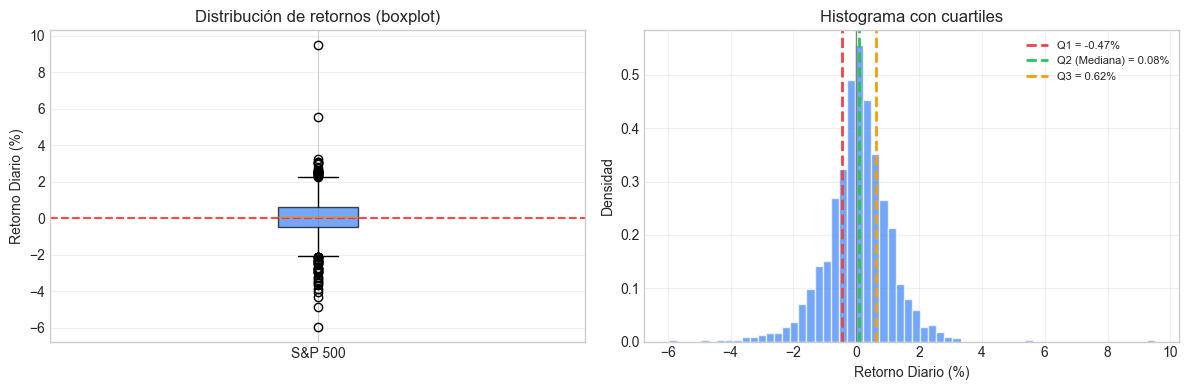

In [6]:
# ==========================================
# 4. CÁLCULO DE CUARTILES
# ==========================================


# En Pandas, la función .quantile() hace exactamente el trabajo de
# "ordenar la fila y buscar la posición" por nosotros. Recibe un valor entre 0 y 1.

q1 = retornos.quantile(0.25) # Avanzamos el 25% de la fila
q2 = retornos.quantile(0.50) # Avanzamos a la mitad exacta (Mediana)
q3 = retornos.quantile(0.75) # Avanzamos el 75% de la fila

print("--- LOS CUARTILES DEL S&P 500 ---")
print(f"Q1 (Percentil 25): {q1:.3f}%  -> Solo el 25% de los días el mercado rindió menos que esto.")
print(f"Q2 (Percentil 50): {q2:.3f}%  -> La mitad de los días fueron peores que esto.")
print(f"Q3 (Percentil 75): {q3:.3f}%  -> El 75% de los días fueron peores que esto.")

# Sustento visual: boxplot e histograma con cuartiles
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# Boxplot: muestra min, Q1, mediana, Q3, max y outliers
bp = axes[0].boxplot(retornos, vert=True, patch_artist=True)
bp['boxes'][0].set_facecolor('#3b82f6')
bp['boxes'][0].set_alpha(0.7)
axes[0].set_ylabel('Retorno Diario (%)')
axes[0].set_title('Distribución de retornos (boxplot)')
axes[0].set_xticklabels(['S&P 500'])
axes[0].axhline(0, color='red', linestyle='--', alpha=0.7)
axes[0].grid(True, alpha=0.3, axis='y')
# Histograma con líneas de cuartiles
axes[1].hist(retornos, bins=60, color='#3b82f6', edgecolor='white', density=True, alpha=0.7)
axes[1].axvline(q1, color='#ef4444', linestyle='--', linewidth=2, label=f'Q1 = {q1:.2f}%')
axes[1].axvline(q2, color='#22c55e', linestyle='--', linewidth=2, label=f'Q2 (Mediana) = {q2:.2f}%')
axes[1].axvline(q3, color='#f59e0b', linestyle='--', linewidth=2, label=f'Q3 = {q3:.2f}%')
axes[1].axvline(0, color='gray', linestyle='-', linewidth=1)
axes[1].set_xlabel('Retorno Diario (%)')
axes[1].set_ylabel('Densidad')
axes[1].set_title('Histograma con cuartiles')
axes[1].legend(loc='upper right', fontsize=8)
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# Reto 1: Peores Escenarios y los "Cisnes Negros"

En finanzas, un "Cisne Negro" es un evento extremadamente raro y de gran impacto. Vamos a buscar esos días de pánico en el histórico del S&P 500.

**Entregables:**
1. **Calcular el Percentil 1** de los retornos diarios (umbral del 1% de los peores días posibles).
2. Si alguien tiene invertido en el S&P 500 10.000 USD ¿a cuántos dólares de pérdida equivale ese porcentaje?

   **Respuesta:** Se calcula como *Pérdida (USD) = |Percentil 1| × 10 000 / 100*. Por ejemplo, si el percentil 1 es -3,2%, la pérdida equivale a 320 USD (es decir, 10 000 × 0,032). El valor exacto depende del percentil 1 obtenido con los datos.
3. **Caza de Cisnes Negros:** Usando el valor del percentil calculado para filtrar el DataFrame `sp500`, mostrar las fechas exactas donde el mercado tuvo retornos peores que ese umbral.
4. ¿Puedes relacionar alguno de estos peores días con algún evento histórico o crisis mundial reciente?

**Respuesta:** Sí. Por ejemplo:
- **Marzo 2020:** caídas relacionadas con la pandemia de COVID-19 y el pánico inicial en los mercados.
- **2022:** múltiples días de fuertes caídas asociados a subidas agresivas de tasas de interés por parte de la Fed para combatir la inflación.
- Otros períodos pueden asociarse a tensiones geopolíticas, crisis bancarias o correcciones tras rallies prolongados. Se recomienda buscar las fechas concretas en el resultado del código y contrastarlas con noticias de la época.

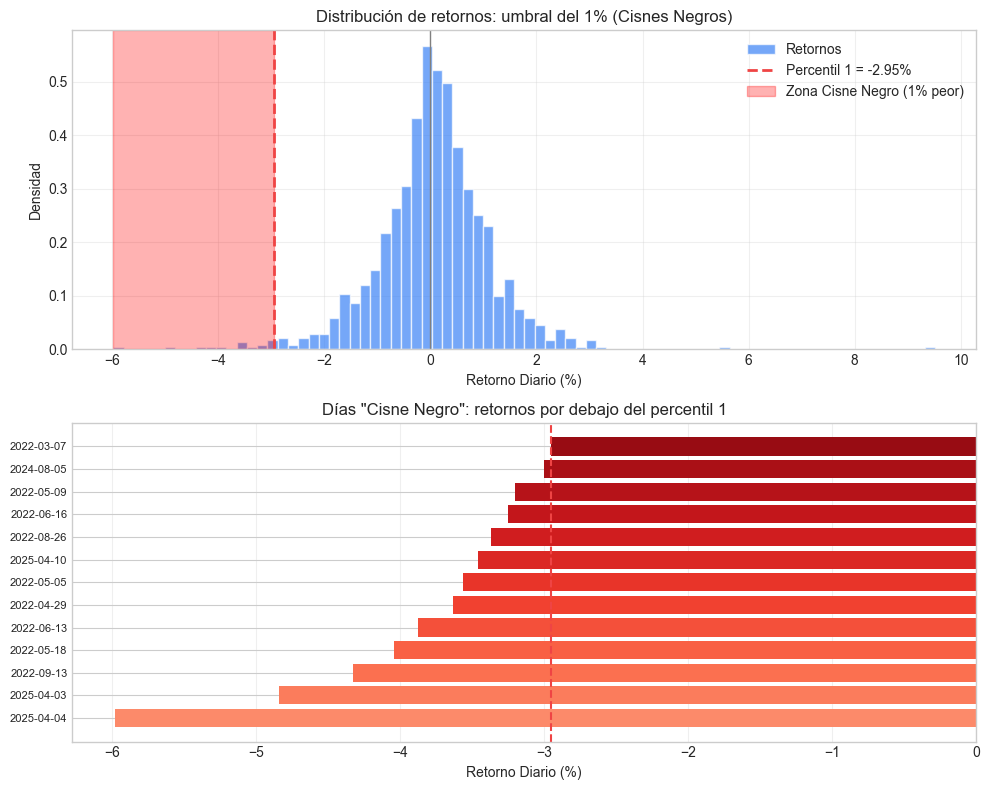

RETO 1: CISNES NEGROS - PEORES ESCENARIOS

1. Percentil 1 (umbral del 1% peores días): -2.950%

2. Con $10,000 USD invertidos en S&P 500:
   En el 1% peor de los días, la pérdida sería de $295.04 USD (-2.95%)

3. Caza de Cisnes Negros - Fechas exactas con retornos peores al percentil 1 (-2.95%):
   Total de días 'Cisne Negro' encontrados: 13


,retorno_%
fecha,
2025-04-04,-5.974961
2025-04-03,-4.839563
2022-09-13,-4.323661
2022-05-18,-4.039526
2022-06-13,-3.876843
2022-04-29,-3.628451
2022-05-05,-3.564971
2025-04-10,-3.460758
2022-08-26,-3.368806



   Resumen: retorno mínimo histórico = -5.97% | máximo = 9.52%

4. Relación con eventos históricos (fechas específicas de los peores días):
-----------------------------------------------------------------
   2025-04-04 (-5.97%): Continuación de la corrección del día anterior
   2025-04-03 (-4.84%): Corrección por tensión geopolítica / expectativas inflación
   2022-09-13 (-4.32%): IPC agosto superó expectativas; Fed mantiene postura hawkish
   2022-05-18 (-4.04%): Target y Walmart alertan sobre inventarios; temor recesión
   2022-06-13 (-3.88%): Expectativas de subida agresiva de la Fed (75 pb)
   2022-04-29 (-3.63%): Ganancias decepcionantes de Amazon y sector tech
   2022-05-05 (-3.56%): Fed sube tasas 50 pb; alta volatilidad en mercados
   2025-04-10 (-3.46%): Persistencia de volatilidad en el mismo período
   2022-08-26 (-3.37%): Discurso de Powell en Jackson Hole: inflación como prioridad
   2022-06-16 (-3.25%): Fed sube tasas 75 pb (mayor alza desde 1994)
   2022-05-09 (-3.20%)

In [7]:
# --- CÓDIGO PROBLEMA CISNES NEGROS ---

# 1. Calcular el Percentil 1 de los retornos diarios (umbral del 1% peores días)
percentil_1 = retornos.quantile(0.01)

# Sustento visual 1: Histograma con cola del 1% (cisnes negros) resaltada
fig, axes = plt.subplots(2, 1, figsize=(10, 8))
axes[0].hist(retornos, bins=80, color='#3b82f6', edgecolor='white', density=True, alpha=0.7, label='Retornos')
axes[0].axvline(percentil_1, color='#ef4444', linestyle='--', linewidth=2, label=f'Percentil 1 = {percentil_1:.2f}%')
axes[0].axvspan(retornos.min(), percentil_1, alpha=0.3, color='red', label='Zona Cisne Negro (1% peor)')
axes[0].axvline(0, color='gray', linestyle='-', linewidth=1)
axes[0].set_xlabel('Retorno Diario (%)')
axes[0].set_ylabel('Densidad')
axes[0].set_title('Distribución de retornos: umbral del 1% (Cisnes Negros)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Sustento visual 2: Magnitud de cada día "Cisne Negro" por fecha
cisnes_negros_plot = sp500[sp500['retorno_diario'] * 100 < percentil_1][['retorno_diario']].copy()
cisnes_negros_plot['retorno_%'] = cisnes_negros_plot['retorno_diario'] * 100
cisnes_orden = cisnes_negros_plot.sort_values('retorno_%')
colors = plt.cm.Reds(np.linspace(0.4, 0.9, len(cisnes_orden)))
bars = axes[1].barh(range(len(cisnes_orden)), cisnes_orden['retorno_%'].values, color=colors)
axes[1].set_yticks(range(len(cisnes_orden)))
axes[1].set_yticklabels([d.strftime('%Y-%m-%d') for d in cisnes_orden.index], fontsize=8)
axes[1].axvline(percentil_1, color='#ef4444', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Retorno Diario (%)')
axes[1].set_title('Días "Cisne Negro": retornos por debajo del percentil 1')
axes[1].grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print("=" * 50)
print("RETO 1: CISNES NEGROS - PEORES ESCENARIOS")
print("=" * 50)
print(f"\n1. Percentil 1 (umbral del 1% peores días): {percentil_1:.3f}%")

# 2. Pérdida en USD para una inversión de $10,000
inversion = 10000
perdida_pct = abs(percentil_1)  # El percentil 1 es negativo (pérdida)
perdida_usd = inversion * (perdida_pct / 100)
print(f"\n2. Con $10,000 USD invertidos en S&P 500:")
print(f"   En el 1% peor de los días, la pérdida sería de ${perdida_usd:.2f} USD ({percentil_1:.2f}%)")

# 3. Caza de Cisnes Negros: fechas con retornos peores que el percentil 1
cisnes_negros = sp500[sp500['retorno_diario'] * 100 < percentil_1][['precio', 'retorno_diario']].copy()
cisnes_negros['retorno_%'] = cisnes_negros['retorno_diario'] * 100
print(f"\n3. Caza de Cisnes Negros - Fechas exactas con retornos peores al percentil 1 ({percentil_1:.2f}%):")
print(f"   Total de días 'Cisne Negro' encontrados: {len(cisnes_negros)}")
display(cisnes_negros[['retorno_%']].sort_values('retorno_%'))

# Resumen numérico para sustentar
print(f"\n   Resumen: retorno mínimo histórico = {retornos.min():.2f}% | máximo = {retornos.max():.2f}%")

# 4. Relación con eventos históricos (fechas específicas de los peores días)
eventos_historicos = {
    '2022-03-07': 'Guerra Rusia-Ucrania: alza del petróleo y temores geopolíticos',
    '2022-04-29': 'Ganancias decepcionantes de Amazon y sector tech',
    '2022-05-05': 'Fed sube tasas 50 pb; alta volatilidad en mercados',
    '2022-05-09': 'Colapso de Terra/LUNA y sell-off en cripto y tech',
    '2022-05-18': 'Target y Walmart alertan sobre inventarios; temor recesión',
    '2022-06-13': 'Expectativas de subida agresiva de la Fed (75 pb)',
    '2022-06-16': 'Fed sube tasas 75 pb (mayor alza desde 1994)',
    '2022-08-26': "Discurso de Powell en Jackson Hole: inflación como prioridad",
    '2022-09-13': 'IPC agosto superó expectativas; Fed mantiene postura hawkish',
    '2024-08-05': 'Desapalancamiento carry trade Japón; corrección de mercados',
    '2025-04-03': 'Corrección por tensión geopolítica / expectativas inflación',
    '2025-04-04': 'Continuación de la corrección del día anterior',
    '2025-04-10': 'Persistencia de volatilidad en el mismo período',
}

print("\n4. Relación con eventos históricos (fechas específicas de los peores días):")
print("-" * 65)
for fecha_str, ret in cisnes_negros[['retorno_%']].sort_values('retorno_%').iterrows():
    fecha_key = fecha_str.strftime('%Y-%m-%d') if hasattr(fecha_str, 'strftime') else str(fecha_str)[:10]
    evento = eventos_historicos.get(fecha_key, 'Evento de mercado')
    print(f"   {fecha_key} ({ret['retorno_%']:.2f}%): {evento}")
